In [2]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("android_apps_dataset_social.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

Dataset shape: (200, 19)

Columns:
['AppID', 'AppName', 'Category', 'Camera', 'Location', 'Contacts', 'Microphone', 'Storage', 'SMS', 'CallLogs', 'Bluetooth', 'Calendar', 'PhoneState', 'Internet', 'ReadPhoneNumbers', 'PrivacyRiskScore', 'TrueLabel', 'NoisyLabel', 'LabelFlipped']

First 5 rows:
     AppID      AppName Category  Camera  Location  Contacts  Microphone  \
0  SOC0001  PrimeSocial   Social       1         1         1           1   
1  SOC0002     SmartHub   Social       1         1         1           0   
2  SOC0003   OrbitSpace   Social       1         0         1           1   
3  SOC0004     BlueNest   Social       1         0         1           1   
4  SOC0005      FunNest   Social       1         1         1           1   

   Storage  SMS  CallLogs  Bluetooth  Calendar  PhoneState  Internet  \
0        1    0         0          0         0           0         1   
1        0    0         0          0         0           0         1   
2        0    0         0       

In [3]:
# --------------------------------------------------
# STEP 1: Remove duplicate rows
# --------------------------------------------------

print("Rows before duplicate removal:", len(df))

df = df.drop_duplicates()

print("Rows after duplicate removal:", len(df))


# --------------------------------------------------
# STEP 2: Identify permission columns
# --------------------------------------------------

permission_columns = [
    "Camera",
    "Location",
    "Contacts",
    "Microphone",
    "Storage",
    "SMS",
    "CallLogs",
    "Bluetooth",
    "Calendar",
    "PhoneState",
    "Internet",
    "ReadPhoneNumbers"
]

print("\nPermission columns:")
print(permission_columns)


# --------------------------------------------------
# STEP 3: Handle missing values
# --------------------------------------------------

# Numeric permission columns
df[permission_columns] = df[permission_columns].fillna(0)

# Privacy risk score
df["PrivacyRiskScore"] = df["PrivacyRiskScore"].fillna(
    df["PrivacyRiskScore"].median()
)

# Categorical columns
df["Category"] = df["Category"].fillna("Unknown")
df["TrueLabel"] = df["TrueLabel"].fillna("Unknown")


# --------------------------------------------------
# STEP 4: Convert permissions to binary
# --------------------------------------------------

for col in permission_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)
    df[col] = (df[col] > 0).astype(int)


# --------------------------------------------------
# STEP 5: Encode TrueLabel
# --------------------------------------------------

df["LabelEncoded"] = df["TrueLabel"].map({
    "Benign": 0,
    "Malicious": 1
})


# --------------------------------------------------
# STEP 6: Encode category
# --------------------------------------------------

# Your current dataset has only "Social".
# Therefore one-hot encoding produces a constant column,
# which is not useful for ML/ranking.

df["CategoryEncoded"] = df["Category"].astype("category").cat.codes


print("\nAfter preprocessing:")
print(df.head())

print("\nMissing values:")
print(df.isnull().sum())

Rows before duplicate removal: 200
Rows after duplicate removal: 200

Permission columns:
['Camera', 'Location', 'Contacts', 'Microphone', 'Storage', 'SMS', 'CallLogs', 'Bluetooth', 'Calendar', 'PhoneState', 'Internet', 'ReadPhoneNumbers']

After preprocessing:
     AppID      AppName Category  Camera  Location  Contacts  Microphone  \
0  SOC0001  PrimeSocial   Social       1         1         1           1   
1  SOC0002     SmartHub   Social       1         1         1           0   
2  SOC0003   OrbitSpace   Social       1         0         1           1   
3  SOC0004     BlueNest   Social       1         0         1           1   
4  SOC0005      FunNest   Social       1         1         1           1   

   Storage  SMS  CallLogs  ...  Calendar  PhoneState  Internet  \
0        1    0         0  ...         0           0         1   
1        0    0         0  ...         0           0         1   
2        0    0         0  ...         0           0         1   
3        1    0  

In [4]:
# --------------------------------------------------
# PERMISSION MATRIX
# --------------------------------------------------

permission_matrix = df[permission_columns].copy()

# Use AppName as row identifier
permission_matrix.index = df["AppName"]

print("\nPermission Matrix:")
print(permission_matrix.head())


Permission Matrix:
             Camera  Location  Contacts  Microphone  Storage  SMS  CallLogs  \
AppName                                                                       
PrimeSocial       1         1         1           1        1    0         0   
SmartHub          1         1         1           0        0    0         0   
OrbitSpace        1         0         1           1        0    0         0   
BlueNest          1         0         1           1        1    0         1   
FunNest           1         1         1           1        0    1         0   

             Bluetooth  Calendar  PhoneState  Internet  ReadPhoneNumbers  
AppName                                                                   
PrimeSocial          0         0           0         1                 0  
SmartHub             0         0           0         1                 0  
OrbitSpace           0         0           0         1                 0  
BlueNest             0         0           0       

In [5]:
permission_matrix = df.set_index("AppID")[permission_columns]

print(permission_matrix.head())

         Camera  Location  Contacts  Microphone  Storage  SMS  CallLogs  \
AppID                                                                     
SOC0001       1         1         1           1        1    0         0   
SOC0002       1         1         1           0        0    0         0   
SOC0003       1         0         1           1        0    0         0   
SOC0004       1         0         1           1        1    0         1   
SOC0005       1         1         1           1        0    1         0   

         Bluetooth  Calendar  PhoneState  Internet  ReadPhoneNumbers  
AppID                                                                 
SOC0001          0         0           0         1                 0  
SOC0002          0         0           0         1                 0  
SOC0003          0         0           0         1                 0  
SOC0004          0         0           0         1                 0  
SOC0005          1         0           0        

In [5]:
permission_matrix.to_csv("social_permission_matrix.csv")

print("Permission matrix saved.")

Permission matrix saved.


In [6]:
category = df["Category"].iloc[0]

print("Category:", category)

permission_frequency = permission_matrix.sum().sort_values(
    ascending=False
)

print("\nPermission frequency:")
print(permission_frequency)

Category: Social

Permission frequency:
Contacts            159
Camera              158
Microphone          156
Internet            142
Storage             132
Location             65
ReadPhoneNumbers     64
CallLogs             59
SMS                  55
Bluetooth            43
PhoneState           42
Calendar             40
dtype: int64


In [7]:
permission_usage = (
    permission_matrix.mean() * 100
).sort_values(ascending=False)

permission_usage = permission_usage.round(2)

print("\nPermission usage percentage:")
print(permission_usage)


Permission usage percentage:
Contacts            79.5
Camera              79.0
Microphone          78.0
Internet            71.0
Storage             66.0
Location            32.5
ReadPhoneNumbers    32.0
CallLogs            29.5
SMS                 27.5
Bluetooth           21.5
PhoneState          21.0
Calendar            20.0
dtype: float64


In [8]:
frequency_score = permission_matrix.sum()

frequency_rank = frequency_score.rank(
    ascending=False,
    method="min"
).astype(int)

frequency_ranking = pd.DataFrame({
    "Permission": permission_columns,
    "Frequency": frequency_score.values,
    "FrequencyRank": frequency_rank.values
})

frequency_ranking = frequency_ranking.sort_values(
    "FrequencyRank"
)

print("\nFrequency Ranking:")
print(frequency_ranking)


Frequency Ranking:
          Permission  Frequency  FrequencyRank
2           Contacts        159              1
0             Camera        158              2
3         Microphone        156              3
10          Internet        142              4
4            Storage        132              5
1           Location         65              6
11  ReadPhoneNumbers         64              7
6           CallLogs         59              8
5                SMS         55              9
7          Bluetooth         43             10
9         PhoneState         42             11
8           Calendar         40             12


In [9]:
privacy_scores = {}

for permission in permission_columns:

    apps_using_permission = df[df[permission] == 1]

    if len(apps_using_permission) > 0:
        privacy_scores[permission] = (
            apps_using_permission["PrivacyRiskScore"].mean()
        )
    else:
        privacy_scores[permission] = 0


privacy_score = pd.Series(privacy_scores)

privacy_rank = privacy_score.rank(
    ascending=False,
    method="min"
).astype(int)


privacy_ranking = pd.DataFrame({
    "Permission": permission_columns,
    "AveragePrivacyRisk": [
        privacy_score[p] for p in permission_columns
    ],
    "PrivacyRiskRank": [
        privacy_rank[p] for p in permission_columns
    ]
})

privacy_ranking = privacy_ranking.sort_values(
    "PrivacyRiskRank"
)

print("\nPrivacy Risk Ranking:")
print(privacy_ranking)


Privacy Risk Ranking:
          Permission  AveragePrivacyRisk  PrivacyRiskRank
6           CallLogs            0.684203                1
11  ReadPhoneNumbers            0.670203                2
5                SMS            0.663164                3
1           Location            0.657462                4
9         PhoneState            0.645357                5
8           Calendar            0.643425                6
7          Bluetooth            0.638907                7
3         Microphone            0.505006                8
0             Camera            0.498620                9
2           Contacts            0.496491               10
4            Storage            0.478439               11
10          Internet            0.468859               12


In [10]:
malicious_rate = {}

for permission in permission_columns:

    apps_using_permission = df[df[permission] == 1]

    if len(apps_using_permission) > 0:

        malicious_rate[permission] = (
            apps_using_permission["LabelEncoded"].mean()
        )

    else:
        malicious_rate[permission] = 0


malicious_score = pd.Series(malicious_rate)

malicious_rank = malicious_score.rank(
    ascending=False,
    method="min"
).astype(int)


malicious_ranking = pd.DataFrame({
    "Permission": permission_columns,
    "MaliciousRate": [
        malicious_score[p] for p in permission_columns
    ],
    "MaliciousRank": [
        malicious_rank[p] for p in permission_columns
    ]
})

malicious_ranking = malicious_ranking.sort_values(
    "MaliciousRank"
)

print("\nMalicious Association Ranking:")
print(malicious_ranking)


Malicious Association Ranking:
          Permission  MaliciousRate  MaliciousRank
6           CallLogs       0.898305              1
5                SMS       0.872727              2
1           Location       0.830769              3
11  ReadPhoneNumbers       0.828125              4
8           Calendar       0.800000              5
9         PhoneState       0.785714              6
7          Bluetooth       0.767442              7
3         Microphone       0.346154              8
0             Camera       0.341772              9
2           Contacts       0.333333             10
4            Storage       0.250000             11
10          Internet       0.246479             12


In [11]:
ranking_df = pd.DataFrame({
    "Permission": permission_columns,

    "FrequencyScore": [
        frequency_score[p] for p in permission_columns
    ],

    "FrequencyRank": [
        frequency_rank[p] for p in permission_columns
    ],

    "PrivacyRisk": [
        privacy_score[p] for p in permission_columns
    ],

    "PrivacyRank": [
        privacy_rank[p] for p in permission_columns
    ],

    "MaliciousRate": [
        malicious_score[p] for p in permission_columns
    ],

    "MaliciousRank": [
        malicious_rank[p] for p in permission_columns
    ]
})

print(ranking_df)

          Permission  FrequencyScore  FrequencyRank  PrivacyRisk  PrivacyRank  \
0             Camera             158              2     0.498620            9   
1           Location              65              6     0.657462            4   
2           Contacts             159              1     0.496491           10   
3         Microphone             156              3     0.505006            8   
4            Storage             132              5     0.478439           11   
5                SMS              55              9     0.663164            3   
6           CallLogs              59              8     0.684203            1   
7          Bluetooth              43             10     0.638907            7   
8           Calendar              40             12     0.643425            6   
9         PhoneState              42             11     0.645357            5   
10          Internet             142              4     0.468859           12   
11  ReadPhoneNumbers        

In [12]:
N = len(permission_columns)

ranking_df["BordaFrequency"] = (
    N - ranking_df["FrequencyRank"]
)

ranking_df["BordaPrivacy"] = (
    N - ranking_df["PrivacyRank"]
)

ranking_df["BordaMalicious"] = (
    N - ranking_df["MaliciousRank"]
)

ranking_df["BordaScore"] = (
    ranking_df["BordaFrequency"]
    + ranking_df["BordaPrivacy"]
    + ranking_df["BordaMalicious"]
)

ranking_df["BordaRank"] = (
    ranking_df["BordaScore"]
    .rank(ascending=False, method="min")
    .astype(int)
)

borda_result = ranking_df.sort_values(
    "BordaRank"
)

print("\n==============================")
print("BORDA PERMISSION RANKING")
print("==============================")

print(
    borda_result[
        [
            "Permission",
            "FrequencyRank",
            "PrivacyRank",
            "MaliciousRank",
            "BordaScore",
            "BordaRank"
        ]
    ].to_string(index=False)
)


BORDA PERMISSION RANKING
      Permission  FrequencyRank  PrivacyRank  MaliciousRank  BordaScore  BordaRank
        CallLogs              8            1              1          26          1
        Location              6            4              3          23          2
ReadPhoneNumbers              7            2              4          23          2
             SMS              9            3              2          22          4
      Microphone              3            8              8          17          5
          Camera              2            9              9          16          6
        Contacts              1           10             10          15          7
      PhoneState             11            5              6          14          8
        Calendar             12            6              5          13          9
       Bluetooth             10            7              7          12         10
         Storage              5           11             11  

In [13]:
# --------------------------------------------------
# GARRETT SCORE TABLE
# --------------------------------------------------

garrett_percentages = np.array([
    2, 5, 10, 15, 20, 25, 30, 35, 40, 45,
    50, 55, 60, 65, 70, 75, 80, 85, 90, 95,
    98
])

garrett_scores = np.array([
    82, 75, 70, 66, 63, 60, 57, 54, 51, 48,
    45, 42, 39, 36, 33, 30, 27, 24, 20, 15,
    10
])


def garrett_score(rank, total_items):

    percentage_position = (
        100 * (rank - 0.5)
    ) / total_items

    score = np.interp(
        percentage_position,
        garrett_percentages,
        garrett_scores
    )

    return score

In [14]:
ranking_df["GarrettFrequency"] = ranking_df.apply(
    lambda row: garrett_score(
        row["FrequencyRank"],
        N
    ),
    axis=1
)

ranking_df["GarrettPrivacy"] = ranking_df.apply(
    lambda row: garrett_score(
        row["PrivacyRank"],
        N
    ),
    axis=1
)

ranking_df["GarrettMalicious"] = ranking_df.apply(
    lambda row: garrett_score(
        row["MaliciousRank"],
        N
    ),
    axis=1
)

In [15]:
ranking_df["GarrettTotal"] = (
    ranking_df["GarrettFrequency"]
    + ranking_df["GarrettPrivacy"]
    + ranking_df["GarrettMalicious"]
)

ranking_df["GarrettRank"] = (
    ranking_df["GarrettTotal"]
    .rank(ascending=False, method="min")
    .astype(int)
)

garrett_result = ranking_df.sort_values(
    "GarrettRank"
)

print("\n==============================")
print("GARRETT PERMISSION RANKING")
print("==============================")

print(
    garrett_result[
        [
            "Permission",
            "FrequencyRank",
            "PrivacyRank",
            "MaliciousRank",
            "GarrettTotal",
            "GarrettRank"
        ]
    ].to_string(index=False)
)


GARRETT PERMISSION RANKING
      Permission  FrequencyRank  PrivacyRank  MaliciousRank  GarrettTotal  GarrettRank
        CallLogs              8            1              1    191.388889            1
ReadPhoneNumbers              7            2              4    168.000000            2
        Location              6            4              3    167.500000            3
             SMS              9            3              2    163.000000            4
      Microphone              3            8              8    137.500000            5
          Camera              2            9              9    133.000000            6
        Contacts              1           10             10    131.944444            7
      PhoneState             11            5              6    122.000000            8
        Calendar             12            6              5    113.611111            9
       Bluetooth             10            7              7    112.500000           10
         Storag

In [16]:
final_ranking = ranking_df[
    [
        "Permission",
        "BordaScore",
        "BordaRank",
        "GarrettTotal",
        "GarrettRank"
    ]
].copy()

final_ranking = final_ranking.sort_values(
    "BordaRank"
)

print("\n==========================================")
print("FINAL PERMISSION FEATURE RANKING")
print("==========================================")

print(final_ranking.to_string(index=False))


FINAL PERMISSION FEATURE RANKING
      Permission  BordaScore  BordaRank  GarrettTotal  GarrettRank
        CallLogs          26          1    191.388889            1
        Location          23          2    167.500000            3
ReadPhoneNumbers          23          2    168.000000            2
             SMS          22          4    163.000000            4
      Microphone          17          5    137.500000            5
          Camera          16          6    133.000000            6
        Contacts          15          7    131.944444            7
      PhoneState          14          8    122.000000            8
        Calendar          13          9    113.611111            9
       Bluetooth          12         10    112.500000           10
         Storage           9         11     96.500000           11
        Internet           8         12     84.722222           12


In [17]:
# ============================================================
# 13. NORMALIZED PERMISSION RISK WEIGHTS
# ============================================================

# Use GarrettTotal as the aggregated importance/risk score
total_garrett = ranking_df["GarrettTotal"].sum()

ranking_df["RiskWeight"] = (
    ranking_df["GarrettTotal"] / total_garrett
)

# Check that weights sum to 1
print("\nSum of risk weights:")
print(ranking_df["RiskWeight"].sum())

# Sort by risk weight
risk_weights = ranking_df[
    [
        "Permission",
        "RiskWeight",
        "GarrettRank",
        "BordaRank"
    ]
].sort_values(
    "RiskWeight",
    ascending=False
)

print("\n==============================================")
print("NORMALIZED PERMISSION RISK WEIGHTS")
print("==============================================")

print(
    risk_weights.to_string(index=False)
)


Sum of risk weights:
0.9999999999999999

NORMALIZED PERMISSION RISK WEIGHTS
      Permission  RiskWeight  GarrettRank  BordaRank
        CallLogs    0.118020            1          1
ReadPhoneNumbers    0.103597            2          2
        Location    0.103289            3          2
             SMS    0.100514            4          4
      Microphone    0.084789            5          5
          Camera    0.082014            6          6
        Contacts    0.081363            7          7
      PhoneState    0.075231            8          8
        Calendar    0.070058            9          9
       Bluetooth    0.069373           10         10
         Storage    0.059507           11         11
        Internet    0.052244           12         12


In [18]:
risk_weights["RiskWeight"] = (
    risk_weights["RiskWeight"]
    .round(4)
)

print(risk_weights)

          Permission  RiskWeight  GarrettRank  BordaRank
6           CallLogs      0.1180            1          1
11  ReadPhoneNumbers      0.1036            2          2
1           Location      0.1033            3          2
5                SMS      0.1005            4          4
3         Microphone      0.0848            5          5
0             Camera      0.0820            6          6
2           Contacts      0.0814            7          7
9         PhoneState      0.0752            8          8
8           Calendar      0.0701            9          9
7          Bluetooth      0.0694           10         10
4            Storage      0.0595           11         11
10          Internet      0.0522           12         12


In [19]:
risk_weights.to_csv(
    "permission_risk_weights.csv",
    index=False
)

In [20]:
# ============================================================
# 14. BASELINE PRIVACY SCORE
# ============================================================

# Create dictionary:
# Permission -> normalized risk weight

permission_weights = dict(
    zip(
        ranking_df["Permission"],
        ranking_df["RiskWeight"]
    )
)

# Calculate weighted privacy score for every app

df["BaselinePrivacyScore"] = 0.0

for permission in permission_columns:

    df["BaselinePrivacyScore"] += (
        df[permission]
        * permission_weights[permission]
    )

# Round score
df["BaselinePrivacyScore"] = (
    df["BaselinePrivacyScore"]
    .round(4)
)

print("\n==============================================")
print("BASELINE PRIVACY SCORES")
print("==============================================")

print(
    df[
        [
            "AppID",
            "AppName",
            "Category",
            "BaselinePrivacyScore"
        ]
    ].head(20).to_string(index=False)
)


BASELINE PRIVACY SCORES
  AppID     AppName Category  BaselinePrivacyScore
SOC0001 PrimeSocial   Social                0.4632
SOC0002    SmartHub   Social                0.3189
SOC0003  OrbitSpace   Social                0.3004
SOC0004    BlueNest   Social                0.4779
SOC0005     FunNest   Social                0.6772
SOC0006    HaloZone   Social                0.3262
SOC0007   SparkVibe   Social                0.7177
SOC0008      GoGrid   Social                0.4038
SOC0009 RapidStream   Social                0.2786
SOC0010  BlueCircle   Social                0.2184
SOC0011   DailyMeet   Social                0.3456
SOC0012    FunShare   Social                0.2482
SOC0013  EchoSocial   Social                0.3599
SOC0014   VividPals   Social                0.2263
SOC0015  UltraBuddy   Social                0.2786
SOC0016   QuickChat   Social                0.1931
SOC0017    MegaWave   Social                0.0848
SOC0018   SparkPost   Social                0.3538
SOC001

In [21]:
# ============================================================
# 15. PRIVACY CLASSIFICATION
# ============================================================

def classify_privacy(score):

    if score < 0.33:
        return "Low"

    elif score < 0.66:
        return "Medium"

    else:
        return "High"


df["PrivacyClassification"] = (
    df["BaselinePrivacyScore"]
    .apply(classify_privacy)
)


print("\n==============================================")
print("PRIVACY CLASSIFICATION")
print("==============================================")

print(
    df[
        [
            "AppID",
            "AppName",
            "BaselinePrivacyScore",
            "PrivacyClassification"
        ]
    ].head(20).to_string(index=False)
)


PRIVACY CLASSIFICATION
  AppID     AppName  BaselinePrivacyScore PrivacyClassification
SOC0001 PrimeSocial                0.4632                Medium
SOC0002    SmartHub                0.3189                   Low
SOC0003  OrbitSpace                0.3004                   Low
SOC0004    BlueNest                0.4779                Medium
SOC0005     FunNest                0.6772                  High
SOC0006    HaloZone                0.3262                   Low
SOC0007   SparkVibe                0.7177                  High
SOC0008      GoGrid                0.4038                Medium
SOC0009 RapidStream                0.2786                   Low
SOC0010  BlueCircle                0.2184                   Low
SOC0011   DailyMeet                0.3456                Medium
SOC0012    FunShare                0.2482                   Low
SOC0013  EchoSocial                0.3599                Medium
SOC0014   VividPals                0.2263                   Low
SOC0015  UltraBu

In [22]:
# ============================================================
# 16. COMPARE DATASET RISK WITH BASELINE PRIVACY SCORE
# ============================================================

comparison = df[
    [
        "AppID",
        "AppName",
        "PrivacyRiskScore",
        "BaselinePrivacyScore",
        "PrivacyClassification",
        "TrueLabel"
    ]
].copy()

print("\n==============================================")
print("PRIVACY SCORE COMPARISON")
print("==============================================")

print(
    comparison.head(20).to_string(index=False)
)


PRIVACY SCORE COMPARISON
  AppID     AppName  PrivacyRiskScore  BaselinePrivacyScore PrivacyClassification TrueLabel
SOC0001 PrimeSocial             0.526                0.4632                Medium    Benign
SOC0002    SmartHub             0.368                0.3189                   Low    Benign
SOC0003  OrbitSpace             0.368                0.3004                   Low    Benign
SOC0004    BlueNest             0.526                0.4779                Medium    Benign
SOC0005     FunNest             0.737                0.6772                  High Malicious
SOC0006    HaloZone             0.368                0.3262                   Low    Benign
SOC0007   SparkVibe             0.737                0.7177                  High Malicious
SOC0008      GoGrid             0.421                0.4038                Medium Malicious
SOC0009 RapidStream             0.316                0.2786                   Low    Benign
SOC0010  BlueCircle             0.263                0

In [23]:
# Normalize existing PrivacyRiskScore to 0-1

min_risk = df["PrivacyRiskScore"].min()
max_risk = df["PrivacyRiskScore"].max()

df["ExistingRiskNormalized"] = (
    (df["PrivacyRiskScore"] - min_risk)
    / (max_risk - min_risk)
)

In [24]:
correlation = df[
    [
        "BaselinePrivacyScore",
        "PrivacyRiskScore"
    ]
].corr().iloc[0, 1]

print(
    "\nCorrelation between baseline privacy score "
    "and dataset PrivacyRiskScore:",
    round(correlation, 4)
)


Correlation between baseline privacy score and dataset PrivacyRiskScore: 0.993


In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# ============================================================
# 19. EVALUATE BASELINE PRIVACY SCORE
# ============================================================

# True labels
y_true = df["TrueLabel"].map({
    "Benign": 0,
    "Malicious": 1
})

# Privacy score threshold
# Score >= 0.50 -> Malicious
# Score < 0.50  -> Benign

threshold = 0.50

y_pred = (
    df["BaselinePrivacyScore"] >= threshold
).astype(int)


# ============================================================
# METRICS
# ============================================================

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred
)

recall = recall_score(
    y_true,
    y_pred
)

f1 = f1_score(
    y_true,
    y_pred
)

roc_auc = roc_auc_score(
    y_true,
    df["BaselinePrivacyScore"]
)


print("\n==============================================")
print("BASELINE PRIVACY SCORE EVALUATION")
print("==============================================")

print("Threshold :", threshold)
print("Accuracy   :", round(accuracy, 4))
print("Precision  :", round(precision, 4))
print("Recall     :", round(recall, 4))
print("F1 Score   :", round(f1, 4))
print("ROC-AUC    :", round(roc_auc, 4))


# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Benign",
            "Malicious"
        ]
    )
)


BASELINE PRIVACY SCORE EVALUATION
Threshold : 0.5
Accuracy   : 0.935
Precision  : 0.9254
Recall     : 0.8857
F1 Score   : 0.9051
ROC-AUC    : 0.975

Confusion Matrix:
[[125   5]
 [  8  62]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.94      0.96      0.95       130
   Malicious       0.93      0.89      0.91        70

    accuracy                           0.94       200
   macro avg       0.93      0.92      0.93       200
weighted avg       0.93      0.94      0.93       200



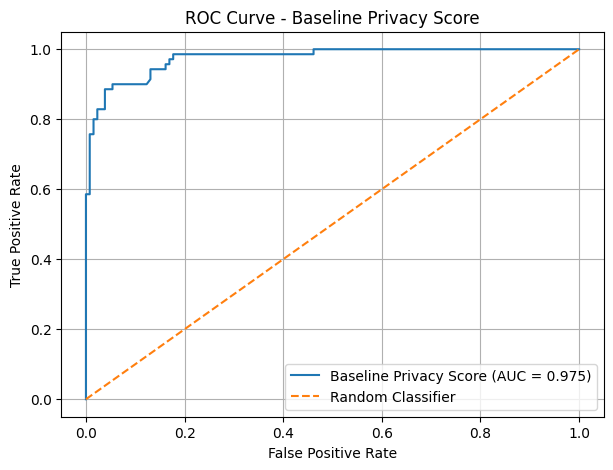

In [27]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(
    y_true,
    df["BaselinePrivacyScore"]
)

auc = roc_auc_score(
    y_true,
    df["BaselinePrivacyScore"]
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Baseline Privacy Score (AUC = {auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Baseline Privacy Score")
plt.legend()
plt.grid(True)

plt.show()

In [28]:
print("\n==============================================")
print("SCORE DISTRIBUTION BY TRUE LABEL")
print("==============================================")

score_summary = (
    df.groupby("TrueLabel")["BaselinePrivacyScore"]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
)

print(
    score_summary.round(4)
)


SCORE DISTRIBUTION BY TRUE LABEL
           count    mean  median     std     min     max
TrueLabel                                               
Benign       130  0.3300  0.3279  0.0931  0.0848  0.6362
Malicious     70  0.6611  0.6742  0.1277  0.3518  0.9306
